# Install and import libraries


In [1]:
!pip install scipy
!pip install scikit-learn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
import os


In [3]:
final_delay_df = pd.read_csv('final_delay_df.csv')
plane_data_df = pd.read_csv('plane-data.csv')

# Reading dataset into main_df for question 2

In [4]:
import pandas as pd
import os

main_df = pd.DataFrame()

# Goes through each year from 1995 to 1999
for year in range(1995, 2000):
    file_name = f"{year}.csv"
    if os.path.exists(file_name): #checking if file exists
        df = pd.read_csv(file_name)

        # Data Cleaning
        df.drop_duplicates(inplace=True)
        #Remove negative values and Null values for time
        df = df[(df['ActualElapsedTime'] >= 0) | (df['ActualElapsedTime'].isna())] #Remove negative values and Null values
        df = df[(df['CRSElapsedTime'] >= 0) | (df['CRSElapsedTime'].isna())] 
        #Remove values greater than 2359 and Null values for 24 hour time
        df = df[(df['DepTime'] <= 2359) | (df['DepTime'].isna())]
        df = df[(df['ArrTime'] <= 2359) | (df['ArrTime'].isna())]                      

        # Append cleaned data to the main DataFrame
        main_df = pd.concat([main_df, df], ignore_index=True)

# Display the first few rows of the final DataFrame
print(main_df.head())


   Year  Month  DayofMonth  DayOfWeek  DepTime  CRSDepTime  ArrTime  \
0  1995      1           6          5    657.0         645    952.0   
1  1995      1           7          6    648.0         645    938.0   
2  1995      1           8          7    649.0         645    932.0   
3  1995      1           9          1    645.0         645    928.0   
4  1995      1          10          2    645.0         645    931.0   

   CRSArrTime UniqueCarrier  FlightNum  ... TaxiIn  TaxiOut  Cancelled  \
0         937            UA        482  ...      7       25          0   
1         937            UA        482  ...      5       17          0   
2         937            UA        482  ...      3       17          0   
3         937            UA        482  ...      3       16          0   
4         937            UA        482  ...      6       18          0   

   CancellationCode  Diverted  CarrierDelay WeatherDelay NASDelay  \
0               NaN         0           NaN          NaN   

In [5]:
main_df['SecurityDelay']

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
            ..
26992102   NaN
26992103   NaN
26992104   NaN
26992105   NaN
26992106   NaN
Name: SecurityDelay, Length: 26992107, dtype: float64

- Columns in main_df

In [6]:
print(main_df.columns)

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
       'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')


# Creating delay_df to answer part (a)

 - taking columns 'Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'ArrTime', 'DepDelay' into delay_df

In [7]:
delay_df = main_df[['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'ArrTime', 'DepDelay']].copy()
print(delay_df.head())

   Year  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  DepDelay
0  1995      1           6          5    657.0    952.0      12.0
1  1995      1           7          6    648.0    938.0       3.0
2  1995      1           8          7    649.0    932.0       4.0
3  1995      1           9          1    645.0    928.0       0.0
4  1995      1          10          2    645.0    931.0       0.0


## Checking for Null values

In [8]:
print(delay_df.isna().sum())

Year               0
Month              0
DayofMonth         0
DayOfWeek          0
DepTime       617022
ArrTime       680419
DepDelay      617022
dtype: int64


## Summary of delay_df

In [9]:
delay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26992107 entries, 0 to 26992106
Data columns (total 7 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Year        int64  
 1   Month       int64  
 2   DayofMonth  int64  
 3   DayOfWeek   int64  
 4   DepTime     float64
 5   ArrTime     float64
 6   DepDelay    float64
dtypes: float64(3), int64(4)
memory usage: 1.4 GB


## Converting 'DayofMonth' and 'DayOfWeek' into their names for easier identification

In [10]:
#Finding unique values for 'DayofMonth' and 'DayOfWeek'
print(delay_df['Month'].unique())
print(delay_df['DayOfWeek'].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12]
[5 6 7 1 2 3 4]


In [11]:
#creating a mapping dataframe for 'DayOfWeek'
day_of_week_mapping = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

#Creating a mapping dataframe for 'Month'  
month_mapping = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

delay_df['DayOfWeekString'] = delay_df['DayOfWeek'].apply(lambda day: day_of_week_mapping[day - 1]) #-1 as python index starts from 0, therefore monday = 1 would be =0 in day_of_week_mapping
delay_df['MonthString'] = delay_df['Month'].apply(lambda month: month_mapping[month - 1]) #similar to above explaination but for the different months

print(delay_df.head())


   Year  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  DepDelay  \
0  1995      1           6          5    657.0    952.0      12.0   
1  1995      1           7          6    648.0    938.0       3.0   
2  1995      1           8          7    649.0    932.0       4.0   
3  1995      1           9          1    645.0    928.0       0.0   
4  1995      1          10          2    645.0    931.0       0.0   

  DayOfWeekString MonthString  
0          Friday     January  
1        Saturday     January  
2          Sunday     January  
3          Monday     January  
4         Tuesday     January  


- checking "MonthString" and "DayOfWeekString" for null values

In [12]:
print(delay_df['MonthString'].isna().sum())
print(delay_df['DayOfWeekString'].isna().sum())

0
0


# Finding Delays

Based on United States Federal Aviation Administration (FAA), a flight is considered to be delayed when it is 15 minutes later than its scheduled time. For part (a), I will be caterizing the delays by the following:


- on_time: less than 15mins delayed

- mild_delay: 15 to 60mins delayed

- moderate_delay: 60 to 180mins delayed 

- severe_delay: more than 180mins delayed 


These will be added to a new column "delay_classification" and will provide on insights on what are the best times of the weeks to book an air ticket. 

## Groupings the data in the dataset by on_time, mild_delay, moderate_delay and severe_delay. 

In [13]:
def delay_classification(time):
    if pd.isna(time):
        return None #If the value is missing
    elif time <= 15: #Delay is less than 15 minutes
        return 'on_time'
    elif time < 60: #Delay is less than 60 minutes
        return 'mild_delay'
    elif time < 180: #Delay is less than 180 minutes
        return 'moderate_delay'
    else:
        return 'severe_delay' #Delay is greater than 180 minutes

delay_df['Delay_classification'] = delay_df['DepDelay'].apply(delay_classification)
print(delay_df.head())

    

   Year  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  DepDelay  \
0  1995      1           6          5    657.0    952.0      12.0   
1  1995      1           7          6    648.0    938.0       3.0   
2  1995      1           8          7    649.0    932.0       4.0   
3  1995      1           9          1    645.0    928.0       0.0   
4  1995      1          10          2    645.0    931.0       0.0   

  DayOfWeekString MonthString Delay_classification  
0          Friday     January              on_time  
1        Saturday     January              on_time  
2          Sunday     January              on_time  
3          Monday     January              on_time  
4         Tuesday     January              on_time  


In [14]:
# Removing missing values in Delay_classification
delay_df.dropna(subset=['Delay_classification'], inplace=True)

In [15]:
# Cheking for missing values in Delay_classification
print(delay_df['Delay_classification'].isna().sum())

0


In [16]:
delay_df['Delay_classification'].value_counts()

Delay_classification
on_time           22182107
mild_delay         3082436
moderate_delay     1007427
severe_delay        103115
Name: count, dtype: int64

# Classifying time of day

We will be grouping the time of day as following:

- Midnight: 0000 to 0559

- Morning: 0600 to 1159

- Afternoon: 1200 to 1759

- Night: 1800 to 2359 

These will be added to a new column "time_of_day" and will provide insights on when is the best time of the day to book an air ticket.


In [17]:
# Creating a function for time of day classification
def time_of_day(time):
    if time <= 559:
        return 'Midnight'
    elif time <= 1159:
        return 'Morning'
    elif time <= 1759:
        return 'Afternoon'
    else:
        return 'Night'

delay_df['Time_of_Day'] = delay_df['DepTime'].apply(time_of_day)

print(delay_df.head())

   Year  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  DepDelay  \
0  1995      1           6          5    657.0    952.0      12.0   
1  1995      1           7          6    648.0    938.0       3.0   
2  1995      1           8          7    649.0    932.0       4.0   
3  1995      1           9          1    645.0    928.0       0.0   
4  1995      1          10          2    645.0    931.0       0.0   

  DayOfWeekString MonthString Delay_classification Time_of_Day  
0          Friday     January              on_time     Morning  
1        Saturday     January              on_time     Morning  
2          Sunday     January              on_time     Morning  
3          Monday     January              on_time     Morning  
4         Tuesday     January              on_time     Morning  


In [18]:
# Checking for missing values in Time_of_Day
print(delay_df['Time_of_Day'].isna().sum())

0


In [19]:
print(delay_df.head()) 

   Year  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  DepDelay  \
0  1995      1           6          5    657.0    952.0      12.0   
1  1995      1           7          6    648.0    938.0       3.0   
2  1995      1           8          7    649.0    932.0       4.0   
3  1995      1           9          1    645.0    928.0       0.0   
4  1995      1          10          2    645.0    931.0       0.0   

  DayOfWeekString MonthString Delay_classification Time_of_Day  
0          Friday     January              on_time     Morning  
1        Saturday     January              on_time     Morning  
2          Sunday     January              on_time     Morning  
3          Monday     January              on_time     Morning  
4         Tuesday     January              on_time     Morning  


# Replacing Month and Days with their respective names (string)

In [20]:
# Creating a mapping list for days of a week and applying it to delay_df
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
delay_df['DayOfWeekString'] = delay_df['DayOfWeek'].apply(lambda day: days[day - 1]) # -1 as python index starts from 0, therefore monday = 1 would be in position 0 in days

# Creating a mapping list for months
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
delay_df['MonthString'] = delay_df['Month'].apply(lambda month: months[month - 1]) # -1 as python index starts from 0, therefore January = 1 would be in position 0 in months

#Finalised main data frame
print(delay_df.head())

   Year  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  DepDelay  \
0  1995      1           6          5    657.0    952.0      12.0   
1  1995      1           7          6    648.0    938.0       3.0   
2  1995      1           8          7    649.0    932.0       4.0   
3  1995      1           9          1    645.0    928.0       0.0   
4  1995      1          10          2    645.0    931.0       0.0   

  DayOfWeekString MonthString Delay_classification Time_of_Day  
0          Friday     January              on_time     Morning  
1        Saturday     January              on_time     Morning  
2          Sunday     January              on_time     Morning  
3          Monday     January              on_time     Morning  
4         Tuesday     January              on_time     Morning  


# Checking for and removing  null values for Delay_classification before using dataframe to answer 2(a)

In [21]:
print(delay_df.isnull().sum())

Year                        0
Month                       0
DayofMonth                  0
DayOfWeek                   0
DepTime                     0
ArrTime                 63397
DepDelay                    0
DayOfWeekString             0
MonthString                 0
Delay_classification        0
Time_of_Day                 0
dtype: int64


In [22]:
# Removing missing values in Delay_classification
delay_df.dropna(subset=['Delay_classification'], inplace=True)

print(delay_df.isnull().sum())

Year                        0
Month                       0
DayofMonth                  0
DayOfWeek                   0
DepTime                     0
ArrTime                 63397
DepDelay                    0
DayOfWeekString             0
MonthString                 0
Delay_classification        0
Time_of_Day                 0
dtype: int64


Since we are finding for delays of departure time, we will continue using the dataset.

In [23]:
final_delay_df = delay_df.copy()

In [24]:
#downloading final data frame
# final_delay_df.to_csv('final_delay_df.csv', index=False)

In [25]:
print(final_delay_df.head())

   Year  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  DepDelay  \
0  1995      1           6          5    657.0    952.0      12.0   
1  1995      1           7          6    648.0    938.0       3.0   
2  1995      1           8          7    649.0    932.0       4.0   
3  1995      1           9          1    645.0    928.0       0.0   
4  1995      1          10          2    645.0    931.0       0.0   

  DayOfWeekString MonthString Delay_classification Time_of_Day  
0          Friday     January              on_time     Morning  
1        Saturday     January              on_time     Morning  
2          Sunday     January              on_time     Morning  
3          Monday     January              on_time     Morning  
4         Tuesday     January              on_time     Morning  


# 2(a) Finding the best time of day to book a plane ticket

## In order to find the best time of day to book a plane ticket, we will be grouping delays by Time_of_Day and 'Delay_classification" and finding the count of each.

In [26]:
grouped_time_df = final_delay_df.value_counts(['Time_of_Day', 'Delay_classification']).reset_index(name='count')
print(grouped_time_df)

   Time_of_Day Delay_classification    count
0      Morning              on_time  9141964
1    Afternoon              on_time  8231207
2        Night              on_time  4491737
3    Afternoon           mild_delay  1312937
4        Night           mild_delay  1067353
5      Morning           mild_delay   674412
6        Night       moderate_delay   491944
7    Afternoon       moderate_delay   348187
8     Midnight              on_time   317199
9      Morning       moderate_delay   142853
10       Night         severe_delay    55171
11    Midnight           mild_delay    27734
12   Afternoon         severe_delay    26983
13    Midnight       moderate_delay    24443
14    Midnight         severe_delay    13183
15     Morning         severe_delay     7778


## To make sense of the data from grouped_by_day_df, we will be finding the percentage of each row.

In [27]:
# calculating the total count of delays for each time of day
total_time_of_day = grouped_time_df.groupby('Time_of_Day')['count'].transform('sum')

# Compute percentage for each row
grouped_time_df['Percentage'] = (grouped_time_df['count'] / total_time_of_day) * 100

# Round to 2 decimal places for readability
grouped_time_df['Percentage'] = grouped_time_df['Percentage'].round(2)

# Display the result
print(grouped_time_df)

   Time_of_Day Delay_classification    count  Percentage
0      Morning              on_time  9141964       91.72
1    Afternoon              on_time  8231207       82.98
2        Night              on_time  4491737       73.56
3    Afternoon           mild_delay  1312937       13.24
4        Night           mild_delay  1067353       17.48
5      Morning           mild_delay   674412        6.77
6        Night       moderate_delay   491944        8.06
7    Afternoon       moderate_delay   348187        3.51
8     Midnight              on_time   317199       82.92
9      Morning       moderate_delay   142853        1.43
10       Night         severe_delay    55171        0.90
11    Midnight           mild_delay    27734        7.25
12   Afternoon         severe_delay    26983        0.27
13    Midnight       moderate_delay    24443        6.39
14    Midnight         severe_delay    13183        3.45
15     Morning         severe_delay     7778        0.08


Plotting a pie chart that shows the proportion of each delay classification. 

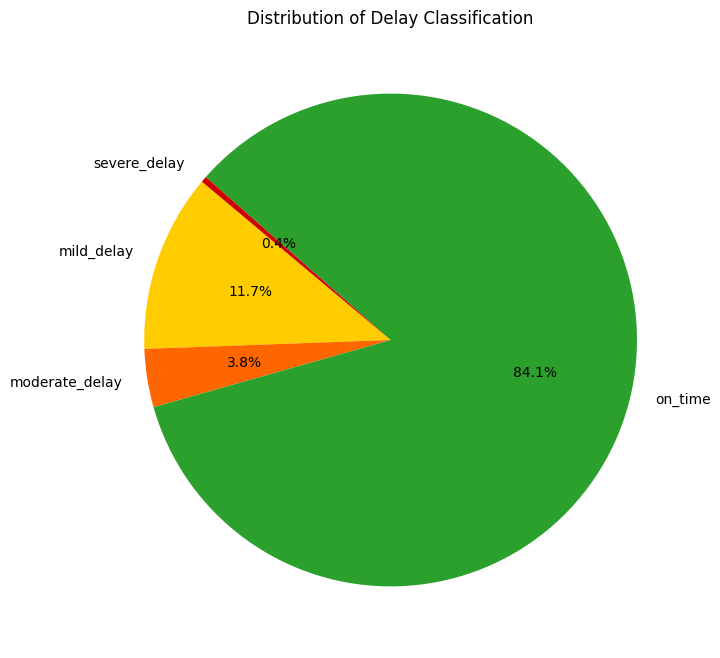

In [28]:
# Aggregate the count for each delay classification
delay_counts = grouped_time_df.groupby("Delay_classification")["count"].sum()

# Define colors for delay classifications (from green to red)
color_map = {
    "on_time": "#2ca02c",  # Green
    "mild_delay": "#ffcc00",  # Yellow
    "moderate_delay": "#ff6600",  # Orange
    "severe_delay": "#cc0000"  # Red
}

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    delay_counts, 
    labels=delay_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=[color_map[label] for label in delay_counts.index]  # Assign colors dynamically
)

# Title
plt.title("Distribution of Delay Classification")

# Show the plot
plt.show()


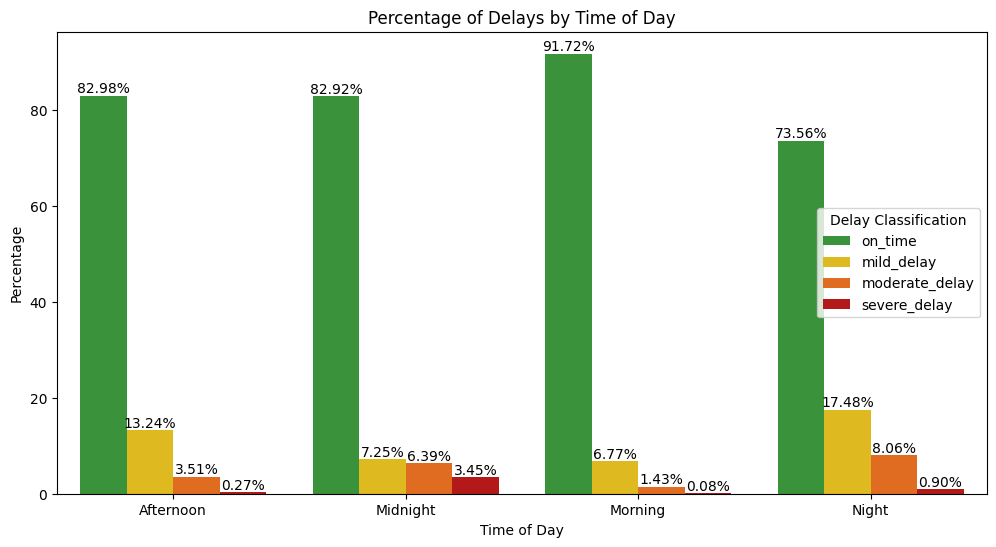

In [29]:
# Define colors for delay classifications (from green to red)
color_map = {
    "on_time": "#2ca02c",  # Green
    "mild_delay": "#ffcc00",  # Yellow
    "moderate_delay": "#ff6600",  # Orange
    "severe_delay": "#cc0000"  # Red
}

# Sort the dataframe so that within each Time_of_Day, bars are sorted in decreasing order of Weighted_Percentage
grouped_time_df = grouped_time_df.sort_values(
    by=["Time_of_Day", "Percentage"], 
    ascending=[True, False]
)

# Set figure size
plt.figure(figsize=(12, 6))

# Create the bar chart
bars = sns.barplot(
    data=grouped_time_df, 
    x="Time_of_Day", 
    y="Percentage", 
    hue="Delay_classification",
    palette=color_map
)

# Add value labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    if height > 0:  # Only label bars with a positive height
        bars.annotate(f'{height:.2f}%', 
                      (bar.get_x() + bar.get_width() / 2, height), 
                      ha='center', va='bottom', fontsize=10, color='black')

# Labels and title
plt.xlabel("Time of Day")
plt.ylabel("Percentage")
plt.title("Percentage of Delays by Time of Day")

# Show the legend
plt.legend(title="Delay Classification")

# Display the plot
plt.show()

Based on the graph above, morning flights have the most flights that are on time at 91.72% of flights, while night flights tend to be delayed more often with only 73.56% of flights being on time. 

# Finding the best day of the week to book flight tickets.

## In order to find the best day of the week to book a plane ticket, we will be grouping delays by "DayOfWeekString" and 'Delay_classification" and finding the count of each.

In [30]:
print(final_delay_df)

          Year  Month  DayofMonth  DayOfWeek  DepTime  ArrTime  DepDelay  \
0         1995      1           6          5    657.0    952.0      12.0   
1         1995      1           7          6    648.0    938.0       3.0   
2         1995      1           8          7    649.0    932.0       4.0   
3         1995      1           9          1    645.0    928.0       0.0   
4         1995      1          10          2    645.0    931.0       0.0   
...        ...    ...         ...        ...      ...      ...       ...   
26992102  1999     12          16          4   1910.0   2112.0       0.0   
26992103  1999     12          17          5   1909.0   2111.0      -1.0   
26992104  1999     12          18          6   1907.0   2103.0      -3.0   
26992105  1999     12          19          7   1907.0   2114.0      -3.0   
26992106  1999     12          20          1   1905.0   2127.0      -5.0   

         DayOfWeekString MonthString Delay_classification Time_of_Day  
0              

In [31]:
grouped_day_df = final_delay_df.value_counts(['DayOfWeekString', 'Delay_classification']).reset_index(name='count')
print(grouped_day_df)

   DayOfWeekString Delay_classification    count
0          Tuesday              on_time  3323708
1           Monday              on_time  3291215
2        Wednesday              on_time  3272046
3         Thursday              on_time  3176584
4           Friday              on_time  3104355
5           Sunday              on_time  3081685
6         Saturday              on_time  2932514
7           Friday           mild_delay   542332
8         Thursday           mild_delay   487843
9           Sunday           mild_delay   447389
10       Wednesday           mild_delay   427296
11          Monday           mild_delay   414765
12         Tuesday           mild_delay   390239
13        Saturday           mild_delay   372572
14          Friday       moderate_delay   181698
15        Thursday       moderate_delay   162929
16       Wednesday       moderate_delay   146372
17          Sunday       moderate_delay   137108
18          Monday       moderate_delay   136948
19         Tuesday  

In [32]:
# calculating the total count of delays for each day of the week
total_day = grouped_day_df.groupby('DayOfWeekString')['count'].transform('sum')

# Compute percentage for each row
grouped_day_df['Percentage'] = (grouped_day_df['count'] / total_day) * 100

# Round to 2 decimal places for readability
grouped_day_df['Percentage'] = grouped_day_df['Percentage'].round(2)

# Display the result
print(grouped_day_df)

   DayOfWeekString Delay_classification    count  Percentage
0          Tuesday              on_time  3323708       86.13
1           Monday              on_time  3291215       85.34
2        Wednesday              on_time  3272046       84.77
3         Thursday              on_time  3176584       82.63
4           Friday              on_time  3104355       80.66
5           Sunday              on_time  3081685       83.74
6         Saturday              on_time  2932514       85.58
7           Friday           mild_delay   542332       14.09
8         Thursday           mild_delay   487843       12.69
9           Sunday           mild_delay   447389       12.16
10       Wednesday           mild_delay   427296       11.07
11          Monday           mild_delay   414765       10.75
12         Tuesday           mild_delay   390239       10.11
13        Saturday           mild_delay   372572       10.87
14          Friday       moderate_delay   181698        4.72
15        Thursday      

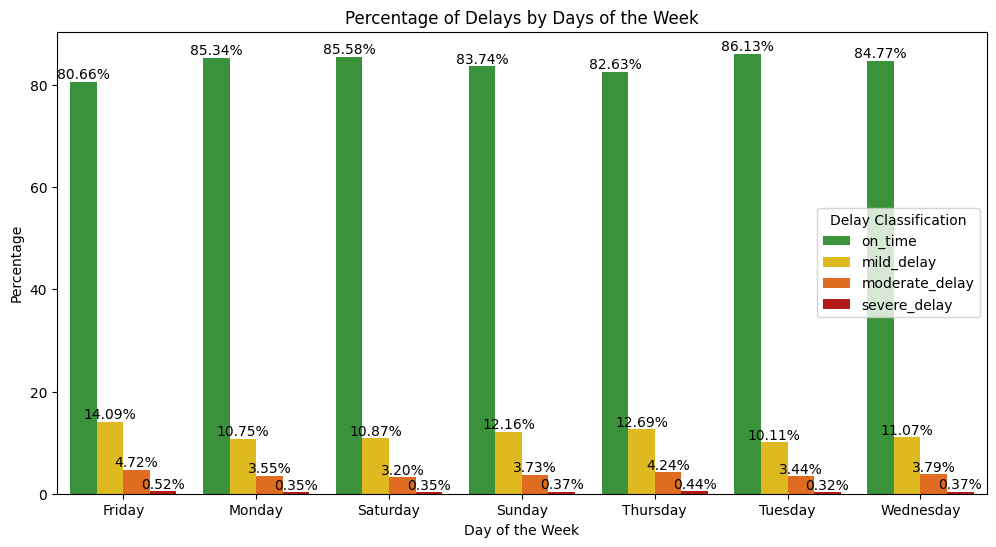

In [33]:
# Define colors for delay classifications (from green to red)
color_map = {
    "on_time": "#2ca02c",  # Green
    "mild_delay": "#ffcc00",  # Yellow
    "moderate_delay": "#ff6600",  # Orange
    "severe_delay": "#cc0000"  # Red
}

# Sort the dataframe so that within each Time_of_Day, bars are sorted in decreasing order of Weighted_Percentage
grouped_day_df = grouped_day_df.sort_values(
    by=["DayOfWeekString", "Percentage"], 
    ascending=[True, False]
)

# Set figure size
plt.figure(figsize=(12, 6))

# Create the bar chart
bars = sns.barplot(
    data=grouped_day_df, 
    x="DayOfWeekString", 
    y="Percentage", 
    hue="Delay_classification",
    palette=color_map
)

# Add value labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    if height > 0:  # Only label bars with a positive height
        bars.annotate(f'{height:.2f}%', 
                      (bar.get_x() + bar.get_width() / 2, height), 
                      ha='center', va='bottom', fontsize=10, color='black')

# Labels and title
plt.xlabel("Day of the Week")
plt.ylabel("Percentage")
plt.title("Percentage of Delays by Days of the Week")

# Show the legend
plt.legend(title="Delay Classification")

# Display the plot
plt.show()

Based on the graph above, Tuesdays has the most flights that are on time at 86.13% while Fridays has the least flights that are on time at 80.66%. 

Hence the best time and day of the week to minimise delays is morning and Tuesdays. 

# Part 2(b) Evaluate wether older planes suffer more delays on a year-to-year basis.



## Classifying wether a plane is old or not 

We will be grouping the planes as following:

- old: more than 20 years old

- young

These will be added to a new column "age_classification" and will provide insights on whether older planes suffer more delays 


## Loading dataset

In [34]:
planes_data_df = pd.read_csv('plane-data.csv')
print(planes_data_df)

     tailnum                 type                   manufacturer  issue_date  \
0     N050AA                  NaN                            NaN         NaN   
1     N051AA                  NaN                            NaN         NaN   
2     N052AA                  NaN                            NaN         NaN   
3     N054AA                  NaN                            NaN         NaN   
4     N055AA                  NaN                            NaN         NaN   
...      ...                  ...                            ...         ...   
5024  N997DL          Corporation  MCDONNELL DOUGLAS AIRCRAFT CO  03/11/1992   
5025  N998AT          Corporation                         BOEING  01/23/2003   
5026  N998DL          Corporation  MCDONNELL DOUGLAS CORPORATION  04/02/1992   
5027  N999CA  Foreign Corporation                       CANADAIR  07/09/2008   
5028  N999DN          Corporation  MCDONNELL DOUGLAS CORPORATION  04/02/1992   

            model status            air

In [35]:
print(planes_data_df.isnull().sum())
print(planes_data_df.info())

tailnum            0
type             549
manufacturer     549
issue_date       550
model            549
status           549
aircraft_type    549
engine_type      552
year             694
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5029 entries, 0 to 5028
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tailnum        5029 non-null   object 
 1   type           4480 non-null   object 
 2   manufacturer   4480 non-null   object 
 3   issue_date     4479 non-null   object 
 4   model          4480 non-null   object 
 5   status         4480 non-null   object 
 6   aircraft_type  4480 non-null   object 
 7   engine_type    4477 non-null   object 
 8   year           4335 non-null   float64
dtypes: float64(1), object(8)
memory usage: 353.7+ KB
None


Combining main_df and planes_data_df using 'tailnum'.

In [36]:
print(planes_data_df.columns)
print(main_df.columns)

Index(['tailnum', 'type', 'manufacturer', 'issue_date', 'model', 'status',
       'aircraft_type', 'engine_type', 'year'],
      dtype='object')
Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
       'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')


Converting all the column names for planes_data_df and main_df into lowercase letters

In [37]:
main_df.columns = main_df.columns.str.lower()
planes_data_df.columns = planes_data_df.columns.str.lower()

print(main_df.columns)
print(planes_data_df.columns)

Index(['year', 'month', 'dayofmonth', 'dayofweek', 'deptime', 'crsdeptime',
       'arrtime', 'crsarrtime', 'uniquecarrier', 'flightnum', 'tailnum',
       'actualelapsedtime', 'crselapsedtime', 'airtime', 'arrdelay',
       'depdelay', 'origin', 'dest', 'distance', 'taxiin', 'taxiout',
       'cancelled', 'cancellationcode', 'diverted', 'carrierdelay',
       'weatherdelay', 'nasdelay', 'securitydelay', 'lateaircraftdelay'],
      dtype='object')
Index(['tailnum', 'type', 'manufacturer', 'issue_date', 'model', 'status',
       'aircraft_type', 'engine_type', 'year'],
      dtype='object')


Merging planes_data_df and main_df using the column 'tailnum' 

In [38]:
merged_df = pd.merge(main_df, planes_data_df, how='inner', left_on='tailnum', right_on='tailnum', suffixes=('main_df', 'planes_data_df'))

In [39]:
print(merged_df.head())

   yearmain_df  month  dayofmonth  dayofweek  deptime  crsdeptime  arrtime  \
0         1995      1           2          1   1148.0        1145   1428.0   
1         1995      1           3          2   1209.0        1145   1450.0   
2         1995      1           7          6   1200.0        1150   1447.0   
3         1995      1           8          7   1151.0        1150   1435.0   
4         1995      1           9          1   1154.0        1150   1433.0   

   crsarrtime uniquecarrier  flightnum  ... securitydelay  lateaircraftdelay  \
0        1435            UA       1845  ...           NaN                NaN   
1        1435            UA       1845  ...           NaN                NaN   
2        1440            UA       1845  ...           NaN                NaN   
3        1440            UA       1845  ...           NaN                NaN   
4        1440            UA       1845  ...           NaN                NaN   

          type  manufacturer  issue_date    model 

In [40]:
print(merged_df.columns)

Index(['yearmain_df', 'month', 'dayofmonth', 'dayofweek', 'deptime',
       'crsdeptime', 'arrtime', 'crsarrtime', 'uniquecarrier', 'flightnum',
       'tailnum', 'actualelapsedtime', 'crselapsedtime', 'airtime', 'arrdelay',
       'depdelay', 'origin', 'dest', 'distance', 'taxiin', 'taxiout',
       'cancelled', 'cancellationcode', 'diverted', 'carrierdelay',
       'weatherdelay', 'nasdelay', 'securitydelay', 'lateaircraftdelay',
       'type', 'manufacturer', 'issue_date', 'model', 'status',
       'aircraft_type', 'engine_type', 'yearplanes_data_df'],
      dtype='object')


In [41]:
merged_df

,yearmain_df,month,dayofmonth,dayofweek,deptime,crsdeptime,arrtime,crsarrtime,uniquecarrier,flightnum,...,securitydelay,lateaircraftdelay,type,manufacturer,issue_date,model,status,aircraft_type,engine_type,yearplanes_data_df
0,1995,1,2,1,1148.0,1145,1428.0,1435,UA,1845,...,NaN,NaN,Corporation,BOEING,04/10/1992,737-522,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1992.0
1,1995,1,3,2,1209.0,1145,1450.0,1435,UA,1845,...,NaN,NaN,Corporation,BOEING,01/06/1992,737-522,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1991.0
2,1995,1,7,6,1200.0,1150,1447.0,1440,UA,1845,...,NaN,NaN,Corporation,BOEING,05/27/1992,737-522,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1992.0
3,1995,1,8,7,1151.0,1150,1435.0,1440,UA,1845,...,NaN,NaN,Corporation,BOEING,03/27/1987,737-322,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1987.0
4,1995,1,9,1,1154.0,1150,1433.0,1440,UA,1845,...,NaN,NaN,Corporation,BOEING,08/07/1991,737-522,Valid,Fixed Wing Multi-Engine,Turbo-Fan,1991.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9748385,1999,12,12,7,1244.0,1246,1454.0,1453,AA,809,...,NaN,NaN,Corporation,MCDONNELL DOUGLAS,08/23/1991,DC-9-82(MD-82),Valid,Fixed Wing Multi-Engine,Turbo-Fan,1991.0
9748386,1999,12,13,1,1244.0,1246,1457.0,1453,AA,809,...,NaN,NaN,Corporation,MCDONNELL DOUGLAS,07/09/1998,DC-9-82(MD-82),Valid,Fixed Wing Multi-Engine,Turbo-Fan,1987.0
9748387,1999,12,1,3,940.0,941,1125.0,1154,AA,1087,...,NaN,NaN,Corporation,MCDONNELL DOUGLAS,06/27/1986,DC-9-82(MD-82),Valid,Fixed Wing Multi-Engine,Turbo-Fan,1986.0
9748388,1999,12,5,7,937.0,943,1158.0,1153,AA,1087,...,NaN,NaN,Corporation,MCDONNELL DOUGLAS,10/31/1989,DC-9-82(MD-82),Valid,Fixed Wing Multi-Engine,Turbo-Fan,1989.0


In [42]:
print(merged_df.isnull().sum())

yearmain_df                 0
month                       0
dayofmonth                  0
dayofweek                   0
deptime                 83628
crsdeptime                  0
arrtime                106632
crsarrtime                  0
uniquecarrier               0
flightnum                   0
tailnum                     0
actualelapsedtime      106632
crselapsedtime           1120
airtime                100992
arrdelay               106632
depdelay                83628
origin                      0
dest                        0
distance                 1500
taxiin                      0
taxiout                     0
cancelled                   0
cancellationcode      9748390
diverted                    0
carrierdelay          9748390
weatherdelay          9748390
nasdelay              9748390
securitydelay         9748390
lateaircraftdelay     9748390
type                   723044
manufacturer           723044
issue_date             723314
model                  723044
status    

We will be choosing and renaming some columns to answer the second question

In [43]:
age_df = merged_df[['yearmain_df', 'flightnum', 'tailnum', 'arrdelay', 'depdelay', 'yearplanes_data_df']].copy()
print(age_df.head())

   yearmain_df  flightnum tailnum  arrdelay  depdelay  yearplanes_data_df
0         1995       1845  N929UA      -7.0       3.0              1992.0
1         1995       1845  N922UA      15.0      24.0              1991.0
2         1995       1845  N933UA       7.0      10.0              1992.0
3         1995       1845  N308UA      -5.0       1.0              1987.0
4         1995       1845  N913UA      -7.0       4.0              1991.0


In [44]:
#Rename yearmain_df to current_year and yearplanes_data_df to plane_year
age_df.rename(columns={'yearmain_df': 'current_year', 'yearplanes_data_df': 'plane_year'}, inplace=True)
age_df.head()

,current_year,flightnum,tailnum,arrdelay,depdelay,plane_year
0,1995,1845,N929UA,-7.0,3.0,1992.0
1,1995,1845,N922UA,15.0,24.0,1991.0
2,1995,1845,N933UA,7.0,10.0,1992.0
3,1995,1845,N308UA,-5.0,1.0,1987.0
4,1995,1845,N913UA,-7.0,4.0,1991.0


Removing null values

In [45]:
#removing null values
age_df = age_df.dropna(subset=['plane_year'])
print(age_df.isnull().sum())

current_year         0
flightnum            0
tailnum              0
arrdelay        102730
depdelay         81885
plane_year           0
dtype: int64


In [46]:
print(age_df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8984362 entries, 0 to 9748389
Data columns (total 6 columns):
 #   Column        Dtype  
---  ------        -----  
 0   current_year  int64  
 1   flightnum     int64  
 2   tailnum       object 
 3   arrdelay      float64
 4   depdelay      float64
 5   plane_year    float64
dtypes: float64(3), int64(2), object(1)
memory usage: 479.8+ MB
None


Converting plane_year to integer for calculating age of plane

In [47]:
#converting plane_year to integer
age_df['plane_year'] = age_df['plane_year'].astype(int)
age_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8984362 entries, 0 to 9748389
Data columns (total 6 columns):
 #   Column        Dtype  
---  ------        -----  
 0   current_year  int64  
 1   flightnum     int64  
 2   tailnum       object 
 3   arrdelay      float64
 4   depdelay      float64
 5   plane_year    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 479.8+ MB


To find year of plane, we will be taking current year minus the issue date.

In [48]:
#calculating age of the plane
age_df['plane_age'] = age_df['current_year'] - age_df['plane_year']
print(age_df.head())

   current_year  flightnum tailnum  arrdelay  depdelay  plane_year  plane_age
0          1995       1845  N929UA      -7.0       3.0        1992          3
1          1995       1845  N922UA      15.0      24.0        1991          4
2          1995       1845  N933UA       7.0      10.0        1992          3
3          1995       1845  N308UA      -5.0       1.0        1987          8
4          1995       1845  N913UA      -7.0       4.0        1991          4


In [49]:
print(age_df.isnull().sum())


current_year         0
flightnum            0
tailnum              0
arrdelay        102730
depdelay         81885
plane_year           0
plane_age            0
dtype: int64


Removing null values for arrival delay and departure delay.

In [50]:
#removing null values from arrdelay and depdelay
age_df = age_df.dropna(subset=['arrdelay', 'depdelay'])
print(age_df.isnull().sum())

current_year    0
flightnum       0
tailnum         0
arrdelay        0
depdelay        0
plane_year      0
plane_age       0
dtype: int64


To find total delay, we will be taking the sum of arrival and departure delay.

In [51]:
age_df['total_delay'] = age_df['arrdelay'] + age_df['depdelay']
print(age_df)

         current_year  flightnum tailnum  arrdelay  depdelay  plane_year  \
0                1995       1845  N929UA      -7.0       3.0        1992   
1                1995       1845  N922UA      15.0      24.0        1991   
2                1995       1845  N933UA       7.0      10.0        1992   
3                1995       1845  N308UA      -5.0       1.0        1987   
4                1995       1845  N913UA      -7.0       4.0        1991   
...               ...        ...     ...       ...       ...         ...   
9748385          1999        809  N585AA       1.0      -2.0        1991   
9748386          1999        809  N440AA       4.0      -2.0        1987   
9748387          1999       1087  N411AA     -29.0      -1.0        1986   
9748388          1999       1087  N499AA       5.0      -6.0        1989   
9748389          1999       1087  N248AA     -14.0      -3.0        1984   

         plane_age  total_delay  
0                3         -4.0  
1                4 

We will now be grouping the dataset by the plane's tail number to get the average delays for each model of plane.

In [52]:
# Group by 'tailnum' to calculate aggregated delay metrics
plane_summary_df = age_df.groupby('tailnum', as_index=False).agg(
    average_arrdelay=('arrdelay', 'mean'),  # Average arrival delay
    average_depdelay=('depdelay', 'mean'),  # Average departure delay
    average_total_delay=('total_delay', 'mean'),  # Average total delay
    plane_age=('plane_age', 'first')  # Assuming plane_age is the same throughout, we will be taking the first value
)
   
print(plane_summary_df)


     tailnum  average_arrdelay  average_depdelay  average_total_delay  \
0     N102UW         10.036585          9.720867            19.757453   
1     N10323          6.577956          7.031444            13.609401   
2     N104UA         11.612069         12.758621            24.370690   
3     N104UW         13.953317         12.506143            26.459459   
4     N105UA         18.342037         19.939948            38.281984   
...      ...               ...               ...                  ...   
1585  N995DL          6.947913          6.938315            13.886228   
1586  N996DL          6.756909          7.774488            14.531397   
1587  N997DL          7.192632          7.418948            14.611580   
1588  N998DL          7.094456          6.890817            13.985273   
1589  N999DN          7.604365          7.150127            14.754492   

      plane_age  
0             1  
1             9  
2             0  
3             0  
4             1  
...         ...

In [53]:
#remove plane age that are less than 0
plane_summary_df = plane_summary_df[plane_summary_df['plane_age'] >= 0]
print(plane_summary_df)

     tailnum  average_arrdelay  average_depdelay  average_total_delay  \
0     N102UW         10.036585          9.720867            19.757453   
1     N10323          6.577956          7.031444            13.609401   
2     N104UA         11.612069         12.758621            24.370690   
3     N104UW         13.953317         12.506143            26.459459   
4     N105UA         18.342037         19.939948            38.281984   
...      ...               ...               ...                  ...   
1585  N995DL          6.947913          6.938315            13.886228   
1586  N996DL          6.756909          7.774488            14.531397   
1587  N997DL          7.192632          7.418948            14.611580   
1588  N998DL          7.094456          6.890817            13.985273   
1589  N999DN          7.604365          7.150127            14.754492   

      plane_age  
0             1  
1             9  
2             0  
3             0  
4             1  
...         ...

In [54]:
#group by plane age
plane_age_groups = plane_summary_df.groupby('plane_age').agg(
    average_arrdelay=('average_arrdelay', 'mean'),  # Average arrival delay
    average_depdelay=('average_depdelay', 'mean'),  # Average departure delay
    average_total_delay=('average_total_delay', 'mean')  # Average total delay
).reset_index()

In [55]:
print(plane_age_groups)

    plane_age  average_arrdelay  average_depdelay  average_total_delay
0           0          7.326230          8.673562            15.999792
1           1          8.416093          8.967139            17.383232
2           2          7.913320          9.134734            17.048054
3           3          7.728569          9.106976            16.835545
4           4          8.269929          9.327734            17.597663
5           5          9.020846          9.820738            18.841584
6           6          9.065361          9.860998            18.926359
7           7          7.530698          8.571384            16.102082
8           8          7.667349          8.443027            16.110376
9           9          7.988028          8.790940            16.778969
10         10          8.328035          9.213888            17.541924
11         11          9.300146          9.601885            18.902031
12         12          7.103832          8.054133            15.157965
13    

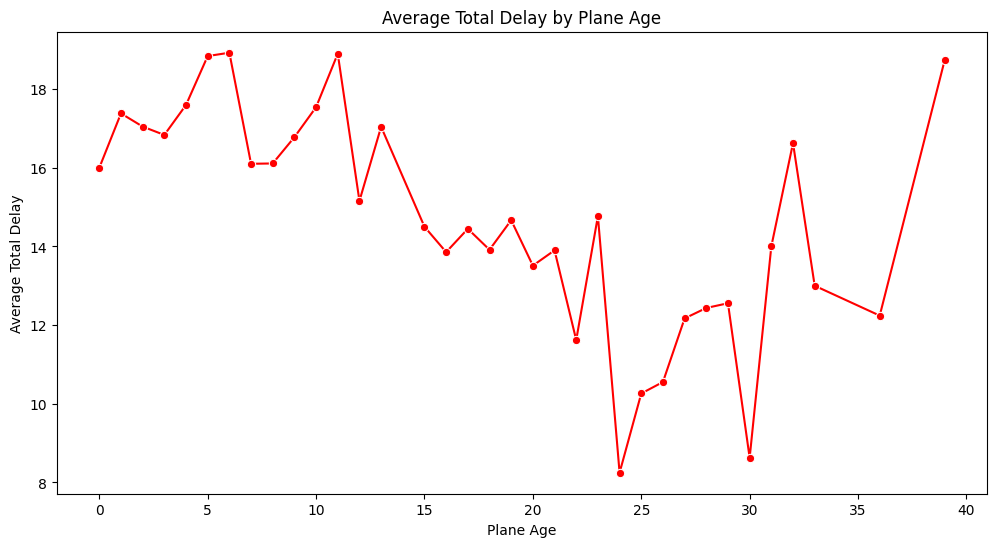

In [62]:
#plotting a graph to show the relationship between plane age and average total delay
plt.figure(figsize=(12, 6))
sns.lineplot(data=plane_age_groups, x='plane_age', y='average_total_delay', marker='o', color='red')

# Labels and title
plt.xlabel("Plane Age")
plt.ylabel("Average Total Delay")
plt.title("Average Total Delay by Plane Age")

# Display the plot
plt.show()


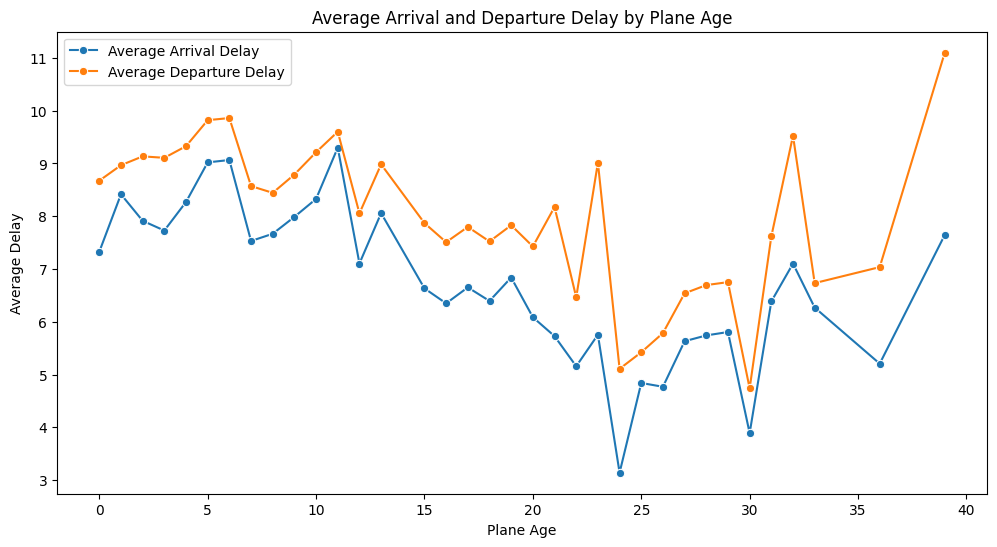

In [57]:
#plotting a graph to show the relationship between plane age and average arrival and departure delay    
plt.figure(figsize=(12, 6))

# Create the line plot for average arrival delay
sns.lineplot(data=plane_age_groups, x='plane_age', y='average_arrdelay', marker='o', label='Average Arrival Delay')

# Create the line plot for average departure delay
sns.lineplot(data=plane_age_groups, x='plane_age', y='average_depdelay', marker='o', label='Average Departure Delay')

# Labels and title
plt.xlabel("Plane Age")
plt.ylabel("Average Delay")
plt.title("Average Arrival and Departure Delay by Plane Age")

# Show the legend
plt.legend()

# Display the plot
plt.show()


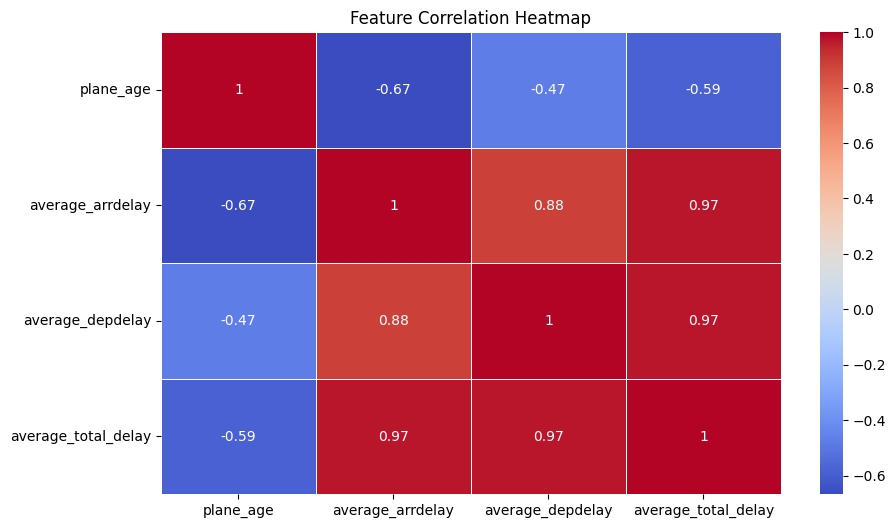

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr_matrix = plane_age_groups.corr()

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Title
plt.title("Feature Correlation Heatmap")

# Show plot
plt.show()


This shows that plane age has a negative correlation between the delays, which supports the graph above, where as plane age increases, delays decrease. This may be counterintuitive.